In [5]:
import os
import cv2
import numpy as np
import supervision as sv
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
def load_model(model_path):
    """
    Load the YOLO model from the specified path.
    
    Args:
        model_path (str): Path to the YOLO model file.
    
    Returns:
        YOLO: Loaded YOLO model.
    """
    return YOLO(model_path)

In [10]:

def run_inference(image_path, height=None, width=None):
    """
    Run inference on a single image.
    """
    image = Image.open(image_path)

    if height is None or width is None:
        height, width = image.size

    image = np.array(image)

    model = load_model('model/best.pt')
    
    results = model.predict(source=image_path, save=True)
    detections = sv.Detections.from_ultralytics(results[0])
    
    bboxes = detections.xyxy
    
    #get count of mosquitoes
    total_mosquitoes = len(bboxes)

    #annotate frame with bounding boxes

    bounding_box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()

    labels = [
        model.model.names[class_id]
        for class_id
        in detections.class_id
    ]

    annotated_image = bounding_box_annotator.annotate(
        scene=image, detections=detections)
    annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections, labels=labels)
    annotated_image = Image.fromarray(annotated_image)
    #calculate density
    density = total_mosquitoes / (height * width)
    print(f"Total Mosquitoes: {total_mosquitoes}, Density: {density:.6f}")

    plt.imshow(annotated_image)
    plt.axis('off')
    plt.show()
    return density, annotated_image



image 1/1 c:\Users\abisoye\Documents\personal\final year projects\feyi\mosquito-detection-app\images\image_13_7.jpg: 480x640 11 mosquitos, 115.6ms
Speed: 2.3ms preprocess, 115.6ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs\detect\predict7
Total Mosquitoes: 11, Density: 0.000023


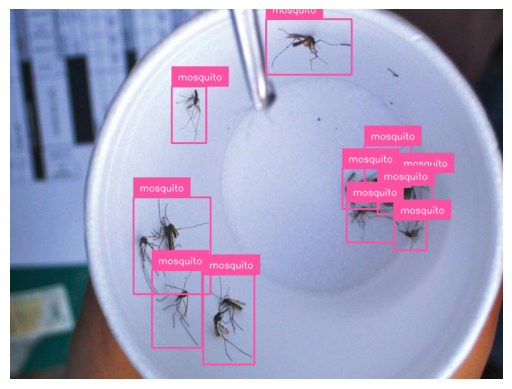

Processed image_13_7.jpg: Density = 0.000023

image 1/1 c:\Users\abisoye\Documents\personal\final year projects\feyi\mosquito-detection-app\images\image_14_0.jpg: 480x640 33 mosquitos, 99.6ms
Speed: 2.1ms preprocess, 99.6ms inference, 10.6ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs\detect\predict8
Total Mosquitoes: 33, Density: 0.000095


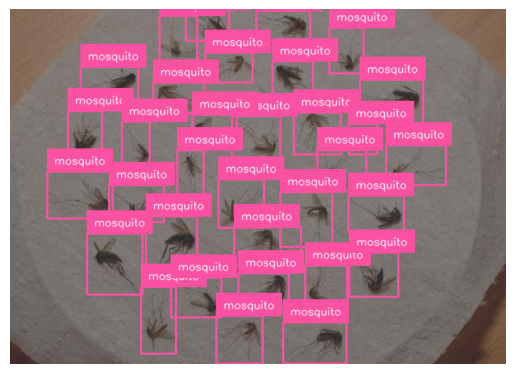

Processed image_14_0.jpg: Density = 0.000095

image 1/1 c:\Users\abisoye\Documents\personal\final year projects\feyi\mosquito-detection-app\images\image_15_14.jpg: 640x384 59 mosquitos, 148.1ms
Speed: 1.7ms preprocess, 148.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)
Results saved to runs\detect\predict9
Total Mosquitoes: 59, Density: 0.000160


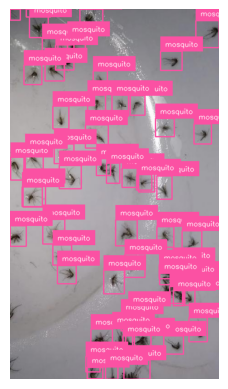

Processed image_15_14.jpg: Density = 0.000160

image 1/1 c:\Users\abisoye\Documents\personal\final year projects\feyi\mosquito-detection-app\images\image_18_13.jpg: 416x640 27 mosquitos, 156.6ms
Speed: 2.1ms preprocess, 156.6ms inference, 0.8ms postprocess per image at shape (1, 3, 416, 640)
Results saved to runs\detect\predict10
Total Mosquitoes: 27, Density: 0.000068


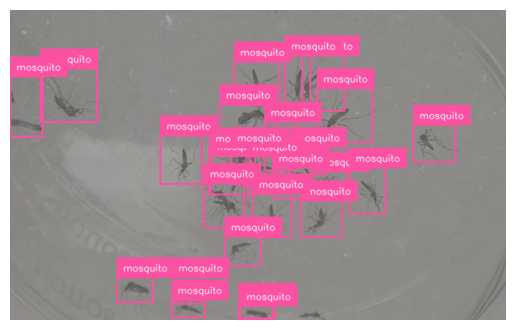

Processed image_18_13.jpg: Density = 0.000068


In [12]:
images_path = 'images'
for file in os.listdir(images_path):
    image_path = os.path.join(images_path, file)
    density, annotated_frame = run_inference(image_path)

    print(f"Processed {file}: Density = {density:.6f}")
    # Save or display the annotated frame if needed
    annotated_frame.save(os.path.join('output', f"annotated_{file}"))